<a href="https://colab.research.google.com/github/Thamil-DSci/int1_Thamil/blob/main/Hilton_TakeHome_Project_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Author: Thamilarasan Ramasamy
# Hilton Take-Home Project: Task-2


 -

# Task 2: Flight Data Simulation, Processing & Analysis

## Overview
Build a **Python 3.7+** program that **simulates, processes, and analyzes flight data**. The task has two phases:

| Phase | Name | Goal |
|---|---|---|
| **1** | Data Generation | Create ~5,000 JSON files of random flight data |
| **2** | Data Analysis & Cleaning | Process the files, clean dirty records, and compute metrics |

---

## Phase 1: Data Generation

**Objective:** Create approximately **5,000 JSON files** with randomly generated flight data and store them in a structured folder hierarchy.

### 1. Folder Structure
Files are stored as:

```
/tmp/flights/%MM-YY%-%origin_city%-flights.json
```

- `%MM-YY%`: the current month and year
- `%origin_city%`: the name of the origin city

### 2. File Contents
- Each file is a **JSON array** of flight records.
- The number of records per file, **M**, is random within **[50 – 100]**.

### 3. Flight Data Fields
| Field | Description |
|---|---|
| `date` | Date of the flight in ISO format (`YYYY-MM-DD`) |
| `origin_city` | City where the flight originated |
| `destination_city` | City where the flight arrived |
| `flight_duration_secs` | Total duration of the flight in seconds |
| `#_of_passengers_on_board` | Number of

##** 0.1 Imports**

In [1]:
import json
import math
import random
import shutil
import sys
import time
from calendar import monthrange
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__)

Python 3.13.15 | pandas 2.2.3 | numpy 2.1.3


### 0.2 Configuration


In [2]:
SEED            = 42
BASE_DIR        = Path("/tmp/flights")   # root output folder
N_FILES         = 5000                   # ~5,000 JSON files
M_RANGE         = (50, 100)              # records per file, M
K_RANGE         = (100, 200)             # size of the city pool, K
L_RANGE         = (0.005, 0.01)          # probability of a dirty record, L (0.5% - 1%)
PASSENGER_RANGE = (20, 400)              # passengers on board per flight

# Field names exactly as specified
F_DATE, F_ORIGIN, F_DEST, F_DUR, F_PAX = (
    "date", "origin_city", "destination_city", "flight_duration_secs", "#_of_passengers_on_board")
FIELDS = [F_DATE, F_ORIGIN, F_DEST, F_DUR, F_PAX]

rng = random.Random(SEED)

## Phase 1 — Data Generation

### 1.1 City name source
A fixed list of 200 real city names

In [3]:
ALL_CITIES = [
    "London", "Paris", "Tokyo", "New York", "Dubai", "Singapore", "Sydney", "Toronto", "Berlin", "Madrid",
    "Rome", "Chicago", "Mumbai", "Delhi", "Beijing", "Shanghai", "Salem", "Bangkok", "Istanbul", "Moscow",
    "Cairo", "Lagos", "Nairobi", "Lima", "Bogota", "Mexico City", "Sao Paulo", "Buenos Aires", "Santiago", "Miami",
    "Boston", "Seattle", "Denver", "Dallas", "Houston", "Atlanta", "Vancouver", "Montreal", "Dublin", "Amsterdam",
    "Brussels", "Vienna", "Zurich", "Prague", "Warsaw", "Stockholm", "Oslo", "Copenhagen", "Helsinki", "Lisbon",
    "Athens", "Doha", "Riyadh", "Tel Aviv", "Karachi", "Dhaka", "Jakarta", "Manila", "Hanoi", "Kuala Lumpur",
    "Hong Kong", "Taipei", "Osaka", "Melbourne", "Auckland", "Johannesburg", "Cape Town", "Casablanca", "Accra", "Addis Ababa",
    "Kyiv", "Budapest", "Bucharest", "Sofia", "Belgrade", "Zagreb", "Munich", "Frankfurt", "Milan", "Barcelona",
    "Manchester", "Edinburgh", "Phoenix", "San Francisco", "Los Angeles", "Las Vegas", "San Diego", "Orlando", "Philadelphia", "Washington",
    "Havana", "Panama City", "Quito", "Caracas", "Montevideo", "Chennai", "Bangalore", "Kolkata", "Lahore", "Tehran",
    "Baghdad", "Kuwait City", "Muscat", "Abu Dhabi", "Amman", "Beirut", "Tunis", "Algiers", "Dakar", "Abuja",
    "Kinshasa", "Luanda", "Harare", "Lusaka", "Dar es Salaam", "Kampala", "Kigali", "Khartoum", "Tashkent", "Almaty",
    "Baku", "Tbilisi", "Yerevan", "Minsk", "Riga", "Vilnius", "Tallinn", "Reykjavik", "Glasgow", "Birmingham",
    "Lyon", "Marseille", "Nice", "Hamburg", "Cologne", "Stuttgart", "Geneva", "Porto", "Valencia", "Seville",
    "Naples", "Venice", "Florence", "Krakow", "Gdansk", "Bratislava", "Ljubljana", "Sarajevo", "Skopje", "Tirana",
    "Chengdu", "Guangzhou", "Shenzhen", "Wuhan", "Xian", "Busan", "Sapporo", "Fukuoka", "Nagoya", "Cebu",
    "Ho Chi Minh City", "Thamil", "Yangon", "Colombo", "Kathmandu", "Islamabad", "Hyderabad", "Ahmedabad", "Pune", "Kochi",
    "Perth", "Brisbane", "Adelaide", "Wellington", "New Mars", "Honolulu", "Anchorage", "Calgary", "Edmonton", "Ottawa",
    "Quebec City", "Minneapolis", "Detroit", "Nashville", "New Orleans", "Austin", "Salt Lake City", "Portland", "Charlotte", "Tampa",
    "Guadalajara", "Monterrey", "Cancun", "San Jose", "Guatemala City", "San Salvador", "Santo Domingo", "Kingston", "Recife", "Rio de Janeiro",
]
assert len(ALL_CITIES) == len(set(ALL_CITIES)) == 200, "city list must have 200 unique names"
print(len(ALL_CITIES), "city names available")

200 city names available


### 1.2 Pick the city pool (K) and give each city a location
- **K** is drawn from [100, 200], and K cities are sampled.
- Each city gets random map coordinates, so a flight's duration depends on the **distance** between its two cities, plus some noise. This makes the AVG/P95 durations differ realistically by destination, instead of being pure noise.

In [4]:
K = rng.randint(*K_RANGE)
CITIES = rng.sample(ALL_CITIES, K)
CITY_XY = {c: (rng.uniform(0, 10000), rng.uniform(0, 10000)) for c in CITIES}   # km on a flat map

def flight_duration_secs(origin, destination):
    # cruise ~800 km/h + 30 min taxi/climb, +/- 10% noise
    (x1, y1), (x2, y2) = CITY_XY[origin], CITY_XY[destination]
    km = math.hypot(x2 - x1, y2 - y1)
    secs = (km / 800 * 3600 + 1800) * rng.uniform(0.9, 1.1)
    return int(round(secs))

print(f"K = {K} cities in the pool, e.g. {CITIES[:5]}")

K = 181 cities in the pool, e.g. ['Santiago', 'Sydney', 'Tampa', 'Kyiv', 'Osaka']


### 1.3 Folder structure: how to get ~5,000 files with unique names
The required file name is `%MM-YY%-%origin_city%-flights.json`, where `%MM-YY%` is the **current** month and year.
With only K ≤ 200 origin cities and a single month, at most K files can have unique names. Writing 5,000 files into one folder would silently **overwrite** most of them.

**My solution: a structured folder hierarchy of batches.**
- Files go into numbered sub-folders, `/tmp/flights/batch_0001/`, `/tmp/flights/batch_0002/`, and so on.
- Each batch holds **one file per origin city** (K files), using the exact required file name.
- Batches are added until ~5,000 files exist.

```
/tmp/flights/
├── batch_0001/
│   ├── 09-26-London-flights.json
│   ├── 09-26-Paris-flights.json
│   └── ...  (K files)
├── batch_0002/
│   └── ...
```

In [5]:
today = date.today()
MM_YY = today.strftime("%m-%y")                           # current month and year, e.g. "09-26"
DAYS_IN_MONTH = monthrange(today.year, today.month)[1]
N_BATCHES = math.ceil(N_FILES / K)

print(f"MM-YY = {MM_YY} | {N_BATCHES} batches x {K} cities = {N_BATCHES * K:,} files")
print("Example path:", BASE_DIR / "batch_0001" / f"{MM_YY}-{CITIES[0]}-flights.json")

MM-YY = 09-26 | 28 batches x 181 cities = 5,068 files
Example path: /tmp/flights/batch_0001/09-26-Santiago-flights.json


### 1.4 Function: generate one flight record
- `date` is a random day in the current month (ISO `YYYY-MM-DD`).
- The destination is any pool city other than the origin.
- With probability **L**, the record becomes *dirty*: 1 to 3 randomly chosen fields are set to `None`, which is written as `null` in JSON.

In [6]:
def make_record(origin, dirty_prob):
    destination = rng.choice([c for c in CITIES if c != origin])
    record = {
        F_DATE:   date(today.year, today.month, rng.randint(1, DAYS_IN_MONTH)).isoformat(),
        F_ORIGIN: origin,
        F_DEST:   destination,
        F_DUR:    flight_duration_secs(origin, destination),
        F_PAX:    rng.randint(*PASSENGER_RANGE),
    }
    is_dirty = rng.random() < dirty_prob
    if is_dirty:
        for field in rng.sample(FIELDS, rng.randint(1, 3)):   # NULL in one or more fields
            record[field] = None
    return record, is_dirty

print(make_record(CITIES[0], dirty_prob=0.0)[0])
print(make_record(CITIES[0], dirty_prob=1.0)[0])   # forced dirty example

{'date': '2026-09-29', 'origin_city': 'Santiago', 'destination_city': 'Ho Chi Minh City', 'flight_duration_secs': 19964, '#_of_passengers_on_board': 132}
{'date': '2026-09-01', 'origin_city': None, 'destination_city': 'Islamabad', 'flight_duration_secs': None, '#_of_passengers_on_board': 362}


### 1.5 Function: write one JSON file
Each file contains a JSON **array** of M records, where M is drawn from [50, 100].
The function returns how many records and dirty records it wrote - these counts are used to verify Phase 2 later.

In [7]:
def write_flight_file(folder, origin, dirty_prob):
    m = rng.randint(*M_RANGE)
    records, n_dirty = [], 0
    for _ in range(m):
        rec, is_dirty = make_record(origin, dirty_prob)
        records.append(rec)
        n_dirty += is_dirty
    path = folder / f"{MM_YY}-{origin}-flights.json"
    with open(path, "w", encoding="utf-8") as fh:
        json.dump(records, fh)
    return m, n_dirty

### 1.6 Run Phase 1: generate all files
- Any previous output is deleted first, so the folder only holds this run.
- **L** is drawn once for the run from [0.5%, 1%].
- The **ground truth** is recorded: exactly how many records, and how many dirty records, were written.

In [8]:
if BASE_DIR.exists():
    shutil.rmtree(BASE_DIR)

L = rng.uniform(*L_RANGE)
truth = {"files": 0, "records": 0, "dirty": 0}
t0 = time.perf_counter()

for b in range(1, N_BATCHES + 1):
    folder = BASE_DIR / f"batch_{b:04d}"
    folder.mkdir(parents=True, exist_ok=True)
    for origin in rng.sample(CITIES, K):
        if truth["files"] >= N_FILES:
            break
        m, n_dirty = write_flight_file(folder, origin, L)
        truth["files"] += 1; truth["records"] += m; truth["dirty"] += n_dirty

print(f"L = {L:.3%} | generated in {time.perf_counter() - t0:.1f}s")
print(f"Ground truth -> files: {truth['files']:,} | records: {truth['records']:,} | dirty: {truth['dirty']:,}")

L = 0.960% | generated in 9.2s
Ground truth -> files: 5,000 | records: 375,234 | dirty: 3,618


### 1.7 Check the output on disk

In [9]:
files = sorted(BASE_DIR.rglob("*-flights.json"))
size_mb = sum(f.stat().st_size for f in files) / 1e6
print(f"{len(files):,} files | {len(list(BASE_DIR.iterdir()))} batch folders | {size_mb:.1f} MB")
print("First file :", files[0])
print("Last file  :", files[-1])
assert len(files) == truth["files"], "file count on disk does not match what was generated"

5,000 files | 28 batch folders | 54.6 MB
First file : /tmp/flights/batch_0001/09-26-Abu Dhabi-flights.json
Last file  : /tmp/flights/batch_0028/09-26-Zagreb-flights.json


### 1.8 inside one file

In [10]:
with open(files[0], encoding="utf-8") as fh:
    sample = json.load(fh)
print(f"{files[0].name}: JSON array with {len(sample)} records\n")
print(json.dumps(sample[:2], indent=2))

09-26-Abu Dhabi-flights.json: JSON array with 86 records

[
  {
    "date": "2026-09-17",
    "origin_city": "Abu Dhabi",
    "destination_city": "San Diego",
    "flight_duration_secs": 20738,
    "#_of_passengers_on_board": 156
  },
  {
    "date": "2026-09-13",
    "origin_city": "Abu Dhabi",
    "destination_city": "San Diego",
    "flight_duration_secs": 22240,
    "#_of_passengers_on_board": 45
  }
]


---
## Phase 2 — Data Analysis & Cleaning

The **analysis timer starts here**. It covers loading, cleaning, the key metrics and the passenger balance.

### 2.1 Load all JSON files into one pandas DataFrame
- **Efficient loading:** each file is parsed once, and all records are collected into a single list. The DataFrame is then built **once**, which is much faster than concatenating 5,000 small DataFrames.
- A `source_file` column keeps lineage, so any bad record can be traced back to its file.

In [11]:
T0 = time.perf_counter()                       # <-- analysis timer starts

records = []
for f in BASE_DIR.rglob("*-flights.json"):
    with open(f, encoding="utf-8") as fh:
        for rec in json.load(fh):
            rec["source_file"] = f"{f.parent.name}/{f.name}"
            records.append(rec)

df_raw = pd.DataFrame.from_records(records, columns=FIELDS + ["source_file"])
del records
t_load = time.perf_counter()
print(f"Loaded {df_raw.shape[0]:,} records from {len(files):,} files in {(t_load - T0) * 1000:,.0f} ms")
df_raw.head()

Loaded 375,234 records from 5,000 files in 2,726 ms


,date,origin_city,destination_city,flight_duration_secs,#_of_passengers_on_board,source_file
0,2026-09-30,Anchorage,Hyderabad,3472.0,188.0,batch_0017/09-26-Anchorage-flights.json
1,2026-09-15,Anchorage,Santiago,28076.0,374.0,batch_0017/09-26-Anchorage-flights.json
2,2026-09-19,Anchorage,Melbourne,31196.0,307.0,batch_0017/09-26-Anchorage-flights.json
3,2026-09-04,Anchorage,Dar es Salaam,20703.0,360.0,batch_0017/09-26-Anchorage-flights.json
4,2026-09-08,Anchorage,Havana,29460.0,375.0,batch_0017/09-26-Anchorage-flights.json


In [15]:
df_raw.shape

(375234, 6)

### 2.2 Identify bad records


In [19]:
null_mask = df_raw[FIELDS].isna()
is_dirty = null_mask.any(axis=1)

print("NULLs per field (a Bad record can have more than one blank or Nulls or NaN):")
print(null_mask.sum().to_string())
df_raw[is_dirty].head()

NULLs per field (a Bad record can have more than one blank or Nulls or NaN):
date                        1475
origin_city                 1424
destination_city            1456
flight_duration_secs        1464
#_of_passengers_on_board    1457


,date,origin_city,destination_city,flight_duration_secs,#_of_passengers_on_board,source_file
56,2026-09-26,Anchorage,None,19657.0,365.0,batch_0017/09-26-Anchorage-flights.json
147,None,Lisbon,Zurich,28162.0,NaN,batch_0017/09-26-Lisbon-flights.json
238,None,Copenhagen,Santo Domingo,25766.0,NaN,batch_0017/09-26-Copenhagen-flights.json
389,2026-09-21,Helsinki,None,27093.0,NaN,batch_0017/09-26-Helsinki-flights.json
403,2026-09-29,None,Caracas,NaN,176.0,batch_0017/09-26-Helsinki-flights.json


### 2.3 Clean: remove bad records and set proper types → `df`
- **Cleaning rule:** bad records are **counted, then removed**. A NULL destination, duration or passenger count cannot be filled in reliably, and guessing values would bias the averages and the passenger balance.
- **Types:**
  - numbers are cast to integers;
  - cities are cast to the memory-efficient `category` type;
  - `date` is parsed to a date type.
- **The clean data is `df`.** Every step from here on uses `df`.

In [20]:
df = df_raw.loc[~is_dirty, FIELDS].copy()
df[F_DUR]    = df[F_DUR].astype("int64")
df[F_PAX]    = df[F_PAX].astype("int64")
df[F_ORIGIN] = df[F_ORIGIN].astype("category")
df[F_DEST]   = df[F_DEST].astype("category")
df[F_DATE]   = pd.to_datetime(df[F_DATE])
df = df.reset_index(drop=True)

total_records = len(df_raw)
Bad_records = int(is_dirty.sum())
t_clean = time.perf_counter()
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371616 entries, 0 to 371615
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   date                      371616 non-null  datetime64[ns]
 1   origin_city               371616 non-null  category      
 2   destination_city          371616 non-null  category      
 3   flight_duration_secs      371616 non-null  int64         
 4   #_of_passengers_on_board  371616 non-null  int64         
dtypes: category(2), datetime64[ns](1), int64(2)
memory usage: 10.0 MB


### 2.4 Result output
The required counts. The runtime shown here covers loading and cleaning only - the **total** analysis runtime is in the final summary (2.8).

In [27]:
pd.DataFrame({"Value": {
    "Total records processed": f"{total_records:,}",
    "Total bad records":     f"{dirty_records:,} ({dirty_records / total_records:.2%})",
    "Clean records in df":     f"{len(df):,}",
    "Runtime so far (ms)":     f"{(t_clean - T0) * 1000:,.0f}",
}})

,Value
Total records processed,"375,234"
Total bad records,"3,618 (0.96%)"
Clean records in df,"371,616"
Runtime so far (ms),"258,980"


### 2.5 Key metrics: Top 25 destinations by passengers arriving
1. Sum `#_of_passengers_on_board` by `destination_city`
2. For each of those cities, computing the **AVG** and **P95** (95th percentile) of `flight_duration_secs`.
   P95 uses pandas `quantile(0.95)` with linear interpolation.

In [28]:
arrivals = df.groupby(F_DEST, observed=True)[F_PAX].sum()
top25 = arrivals.nlargest(25).index

key_metrics = (
    df[df[F_DEST].isin(top25)]
    .groupby(F_DEST, observed=True)[F_DUR]
    .agg(avg_flight_duration_secs="mean",
         p95_flight_duration_secs=lambda s: s.quantile(0.95))
    .join(arrivals.rename("passengers_arrived"))
    .loc[top25]
)
t_metrics = time.perf_counter()

#### Top 25 table (durations also shown as h:mm)

In [29]:
to_hm = lambda s: f"{int(s // 3600)}:{int(s % 3600 // 60):02d}"


In [30]:
top25_table = key_metrics.reset_index().rename(columns={F_DEST: "destination_city"})


In [31]:
top25_table.index = range(1, 26)


In [32]:
top25_table.index.name = "rank"


In [33]:
top25_table["avg (h:mm)"] = top25_table["avg_flight_duration_secs"].map(to_hm)


In [34]:
top25_table["p95 (h:mm)"] = top25_table["p95_flight_duration_secs"].map(to_hm)


In [35]:
top25_table.style.format({"passengers_arrived": "{:,}", "avg_flight_duration_secs": "{:,.1f}",
                          "p95_flight_duration_secs": "{:,.1f}"})

,destination_city,avg_flight_duration_secs,p95_flight_duration_secs,passengers_arrived,avg (h:mm),p95 (h:mm)
rank,,,,,,
1,Nice,"21,871.0","37,628.3","459,520",6:04,10:27
2,Melbourne,"30,638.2","50,113.2","458,126",8:30,13:55
3,Washington,"30,781.9","51,033.2","457,112",8:33,14:10
4,Santo Domingo,"21,055.3","35,781.6","455,833",5:50,9:56
5,Johannesburg,"22,285.2","38,097.8","451,246",6:11,10:34
6,Denver,"25,149.7","42,528.0","450,439",6:59,11:48
7,Istanbul,"32,950.4","51,721.0","450,196",9:09,14:22
8,Cebu,"26,670.9","45,164.5","449,469",7:24,12:32
9,Abuja,"21,417.8","34,092.4","449,436",5:56,9:28


#### Chart: AVG and P95 flight duration for the Top 25

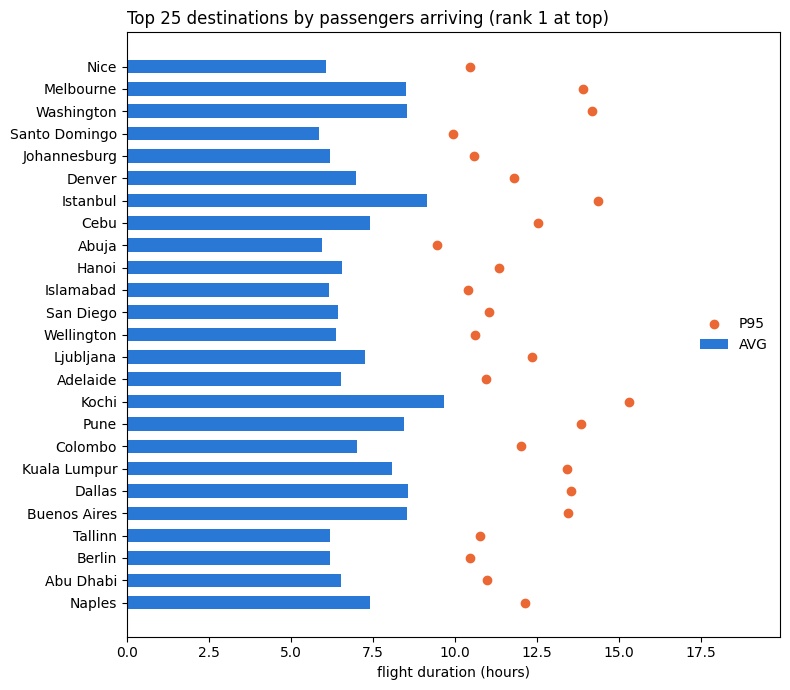

In [36]:
k = top25_table.iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(k["destination_city"], k["avg_flight_duration_secs"] / 3600, color="#2a78d6", height=0.6, label="AVG")
ax.scatter(k["p95_flight_duration_secs"] / 3600, k["destination_city"], color="#eb6834", zorder=3, label="P95")
ax.set_xlabel("flight duration (hours)")
ax.set_title("Top 25 destinations by passengers arriving (rank 1 at top)", loc="left")
ax.set_xlim(0, k["p95_flight_duration_secs"].max() / 3600 * 1.3)
ax.legend(frameon=False, loc="center right")
plt.tight_layout(); plt.show()

### 2.6 Passenger balance per city
- Every city starts with **0** passengers.
- For each flight, the **destination gains** `#_of_passengers_on_board` and the **origin loses** the same number.
- So each city's remaining passengers = **arrived − departed**.

In [37]:
arrived  = df.groupby(F_DEST,   observed=True)[F_PAX].sum().rename(index=str)
departed = df.groupby(F_ORIGIN, observed=True)[F_PAX].sum().rename(index=str)
all_cities = arrived.index.union(departed.index)

balance = pd.DataFrame({
    "arrived":  arrived.reindex(all_cities, fill_value=0),
    "departed": departed.reindex(all_cities, fill_value=0),
})
balance["remaining_passengers"] = 0 + balance["arrived"] - balance["departed"]   # start from 0
balance = balance.sort_values("remaining_passengers", ascending=False)

### 2.7 Cities with the maximum and minimum remaining passengers
Integrity check: every passenger leaves one city and arrives in another, so all balances must **sum to 0**.

In [38]:
assert balance["remaining_passengers"].sum() == 0, "passengers are not conserved"
city_max = balance["remaining_passengers"].idxmax()
city_min = balance["remaining_passengers"].idxmin()
T_END = time.perf_counter()                    # <-- analysis timer stops

print(f"Sum of all balances = {balance['remaining_passengers'].sum()} (passengers conserved)\n")
print(f"MAX remaining passengers: {city_max:<18} {balance.loc[city_max, 'remaining_passengers']:+,}")
print(f"MIN remaining passengers: {city_min:<18} {balance.loc[city_min, 'remaining_passengers']:+,}")
pd.concat([balance.head(5), balance.tail(5)])

Sum of all balances = 0 (passengers conserved)

MAX remaining passengers: Abuja              +68,552
MIN remaining passengers: Bucharest          -55,946


,arrived,departed,remaining_passengers
Abuja,449436,380884,68552
Washington,457112,392543,64569
Dallas,444615,392123,52492
Prague,435635,387635,48000
Abu Dhabi,443180,404312,38868
Bogota,421916,460355,-38439
Rio de Janeiro,411503,453836,-42333
Sao Paulo,427062,475154,-48092
Skopje,402090,454811,-52721
Bucharest,413833,469779,-55946


## A negative remaining_passengers means more passengers flew out of that city than flew in.

#### Chart: 10 highest and 10 lowest balances

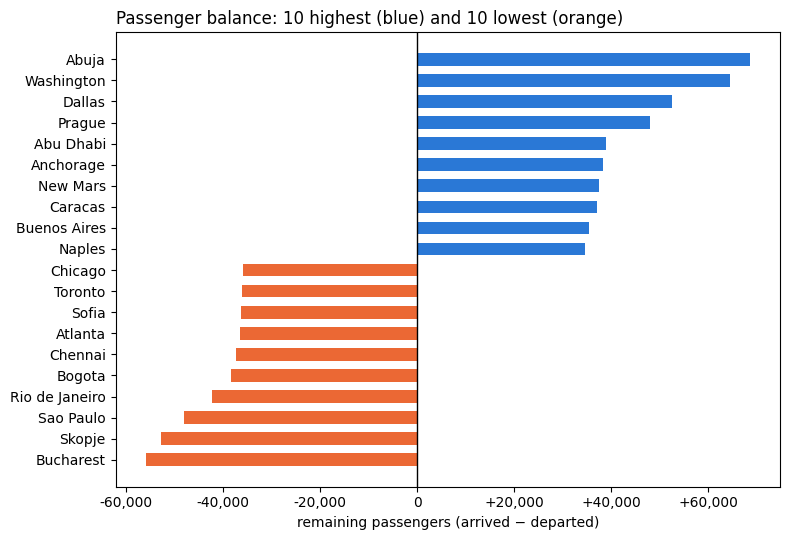

In [39]:
show = pd.concat([balance["remaining_passengers"].head(10), balance["remaining_passengers"].tail(10)]).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(show.index, show.values, color=["#eb6834" if v < 0 else "#2a78d6" for v in show.values], height=0.6)
ax.axvline(0, color="black", lw=1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+,.0f}" if v else "0"))
ax.set_xlabel("remaining passengers (arrived − departed)")
ax.set_title("Passenger balance: 10 highest (blue) and 10 lowest (orange)", loc="left")
plt.tight_layout(); plt.show()

### 2.8 Final summary
Total runtime of the analysis phase, from the first file read (2.1) to the end of the passenger balance (2.7).

In [42]:
pd.DataFrame({"Value": {
    "Total records processed":              f"{total_records:,}",
    "Total bad records":                  f"{dirty_records:,} ({dirty_records / total_records:.2%})",
    "Total runtime of analysis phase (ms)": f"{(T_END - T0) * 1000:,.0f}",
    "  - load (ms)":                        f"{(t_load - T0) * 1000:,.0f}",
    "  - clean (ms)":                       f"{(t_clean - t_load) * 1000:,.0f}",
    "  - key metrics (ms)":                 f"{(t_metrics - t_clean) * 1000:,.0f}",
    "  - passenger balance (ms)":           f"{(T_END - t_metrics) * 1000:,.0f}",
    "Top destination by passengers":        f"{top25[0]} ({arrivals[top25[0]]:,})",
    "City with MAX remaining passengers":   f"{city_max} ({balance.loc[city_max, 'remaining_passengers']:+,})"

}})

,Value
Total records processed,"375,234"
Total bad records,"3,618 (0.96%)"
Total runtime of analysis phase (ms),"951,432"
- load (ms),"2,726"
- clean (ms),"256,254"
- key metrics (ms),"420,234"
- passenger balance (ms),"272,219"
Top destination by passengers,"Nice (459,520)"
City with MAX remaining passengers,"Abuja (+68,552)"


---
## 3. Verification: does Phase 2 match what Phase 1 generated?
Phase 1 recorded exactly how many records and dirty records it wrote.
Phase 2 must count the same, and every rule from the task must hold in the data.

In [43]:
per_file = df_raw.groupby("source_file").size()
dirty_rate = dirty_records / total_records
checks = {
    "records processed == records generated":  total_records == truth["records"],
    "dirty records found == dirty generated":   dirty_records == truth["dirty"],
    f"~{N_FILES:,} files generated":            len(files) == N_FILES,
    "every file has 50-100 records":            per_file.between(*M_RANGE).all(),
    f"city pool K={K} is within [100, 200]":    K_RANGE[0] <= K <= K_RANGE[1],
    "no flight has origin == destination":      (df[F_ORIGIN].astype(str) != df[F_DEST].astype(str)).all(),
    "no NULLs remain in df":                    not df.isna().any().any(),
    "passenger balances sum to 0":              balance["remaining_passengers"].sum() == 0,
}
print(f"Observed dirty rate: {dirty_rate:.3%} (target L = {L:.3%})\n")
print(pd.Series(checks).map({True: "PASS", False: "FAIL"}).to_string())
assert all(checks.values())

Observed dirty rate: 0.964% (target L = 0.960%)

records processed == records generated    PASS
dirty records found == dirty generated    PASS
~5,000 files generated                    PASS
every file has 50-100 records             PASS
city pool K=181 is within [100, 200]      PASS
no flight has origin == destination       PASS
no NULLs remain in df                     PASS
passenger balances sum to 0               PASS


---
## 4. Design notes
| Topic | Decision | Why |
|---|---|---|
| ~5,000 files with unique names | Batch sub-folders (`batch_0001/…`), each with one `%MM-YY%-%origin_city%-flights.json` per city | With one month and K ≤ 200 cities, a single folder can hold at most K unique names; batching avoids silent overwrites while keeping the required file name |
| Realistic durations | City coordinates → distance-based duration ± 10% | AVG/P95 then differ meaningfully by destination |
| Dirty records | 1–3 random fields set to `null` with probability L | Matches "NULL values in one or more fields" |
| Cleaning | Count, then drop | Imputing destinations, durations or passenger counts would invent data and bias the results |
| Efficiency | Single parse per file, one DataFrame build, `category` dtypes, vectorised `groupby` | Linear time and low memory - no Python loops in the metric steps |
| Correctness | Ground-truth counts from Phase 1, plus the balance-sum-to-zero check | Proves the analysis processed every record and classified dirty records exactly |
| Scaling further | Parallel file reading, or DuckDB (`read_json_auto`) / Spark `groupBy` | The aggregations are the same and scale to much larger data |